Explain code:

https://chatgpt.com/c/68e68e6a-2750-8332-bd18-a29be6dfd3d7

In [2]:
# https://www.kaggle.com/shivamkushwaha/bbc-full-text-document-classification
!wget -nc https://lazyprogrammer.me/course_files/nlp/bbc_text_cls.csv

--2025-10-08 21:09:44--  https://lazyprogrammer.me/course_files/nlp/bbc_text_cls.csv
Resolving lazyprogrammer.me (lazyprogrammer.me)... 104.21.23.210, 172.67.213.166, 2606:4700:3030::ac43:d5a6, ...
Connecting to lazyprogrammer.me (lazyprogrammer.me)|104.21.23.210|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5085081 (4.8M) [text/csv]
Saving to: ‘bbc_text_cls.csv’

bbc_text_cls.csv    100%[===================>]   4.85M  --.-KB/s    in 0.1s    

2025-10-08 21:09:44 (37.1 MB/s) - ‘bbc_text_cls.csv’ saved [5085081/5085081]



In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Dense, Input, GlobalMaxPooling1D
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Embedding
from tensorflow.keras.models import Model
from tensorflow.keras.losses import SparseCategoricalCrossentropy

In [4]:
df = pd.read_csv('bbc_text_cls.csv')
df.head()

,text,labels
0,Ad sales boost Time Warner profit\n\nQuarterly...,business
1,Dollar gains on Greenspan speech\n\nThe dollar...,business
2,Yukos unit buyer faces loan claim\n\nThe owner...,business
3,High fuel prices hit BA's profits\n\nBritish A...,business
4,Pernod takeover talk lifts Domecq\n\nShares in...,business


Once a column is categorical, .cat.codes gives each unique category a numeric code. For example:

"negative" → 0

"neutral" → 1

"positive" → 2

In [5]:
df['targets']= df['labels'].astype('category').cat.codes
df.head()

,text,labels,targets
0,Ad sales boost Time Warner profit\n\nQuarterly...,business,0
1,Dollar gains on Greenspan speech\n\nThe dollar...,business,0
2,Yukos unit buyer faces loan claim\n\nThe owner...,business,0
3,High fuel prices hit BA's profits\n\nBritish A...,business,0
4,Pernod takeover talk lifts Domecq\n\nShares in...,business,0


.max(): Finds the maximum integer value in that column. If you have 3 classes (0, 1, 2), the maximum is 2.

\+ 1: Since classes are zero-indexed (start from 0), the number of classes is one more than the maximum index. Example: if max = 2, then K = 3 classes.

K: Stores the total number of classes. Useful later for:

One-hot encoding labels

Setting the output layer of a neural network (Dense(K, activation="softmax")).

In [6]:
# number of classes
K = df['targets'].max() + 1
K

np.int8(5)

In [7]:
df_train, df_test = train_test_split(df,test_size=0.3)
# 0.3 means 30% of the data goes to test, and the remaining 70% goes to train.

In [8]:
# Convert sentences to sequences
MAX_VOCAB_SIZE = 2000
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
tokenizer.fit_on_texts(df_train['text'])
sequences_train = tokenizer.texts_to_sequences(df_train['text'])
sequences_test = tokenizer.texts_to_sequences(df_test['text'])

In [9]:
# get word -> integer mapping
word2idx = tokenizer.word_index
V = len(word2idx)
print('Found %s unique tokens.' % V)

Found 27773 unique tokens.


pads/truncates all sequences to the same length so they can fit into a numeric matrix (needed for deep learning models).

In [10]:
# pad sequences so that we get a N x T matrix
data_train = pad_sequences(sequences_train)
print('Shape of data train tensor:', data_train.shape)

# get sequence length
T = data_train.shape[1]

Shape of data train tensor: (1557, 2853)


In [11]:
data_test = pad_sequences(sequences_test, maxlen=T)
print('Shape of data test tensor:', data_test.shape)

Shape of data test tensor: (668, 2853)


In [12]:
# Create the model

# We get to choose embedding dimensionality
D = 50

# Note: we actually want to the size of the embedding to (V + 1) x D,
# because the first index starts from 1 and not 0.
# Thus, if the final index of the embedding matrix is V,
# then it actually must have size V + 1.

i = Input(shape=(T,))
x = Embedding(V + 1, D)(i)
x = Conv1D(32, 3, activation='relu')(x)
# x = MaxPooling1D(3)(x)
# x = Conv1D(64, 3, activation='relu')(x)
# x = MaxPooling1D(3)(x)
# x = Conv1D(128, 3, activation='relu')(x)
x = GlobalMaxPooling1D()(x)
x = Dense(K)(x)

model = Model(i, x)

In [13]:
# Compile and fit
model.compile(
  loss=SparseCategoricalCrossentropy(from_logits=True),
  optimizer='adam',
  metrics=['accuracy']
)


print('Training model...')
r = model.fit(
  data_train,
  df_train['targets'],
  epochs=50,
  validation_data=(data_test, df_test['targets'])
)

Training model...
Epoch 1/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 176ms/step - accuracy: 0.2921 - loss: 1.5845 - val_accuracy: 0.5853 - val_loss: 1.4598
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 9s 174ms/step - accuracy: 0.6897 - loss: 1.3503 - val_accuracy: 0.7949 - val_loss: 1.0512
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 148ms/step - accuracy: 0.8519 - loss: 0.8743 - val_accuracy: 0.8728 - val_loss: 0.6135
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 11s 166ms/step - accuracy: 0.9227 - loss: 0.4537 - val_accuracy: 0.9012 - val_loss: 0.4092
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 172ms/step - accuracy: 0.9439 - loss: 0.2861 - val_accuracy: 0.9162 - val_loss: 0.3174
Epoch 6/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 176ms/step - accuracy: 0.9617 - loss: 0.1815 - val_accuracy: 0.9237 - val_loss: 0.2643
Epoch 7/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 148ms/step - accuracy: 0.9739 - loss: 0.1383 - val_accuracy: 0.9326 - val_loss: 0.2278
Epoch 8/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 172ms/step - accuracy: 0.9882 - loss: 0.09

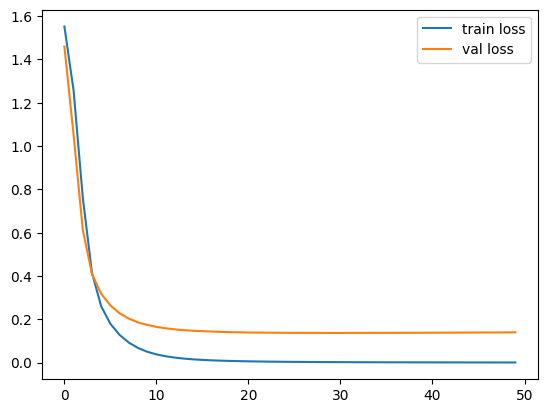

In [14]:
# Plot loss per iteration
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='val loss')
plt.legend();

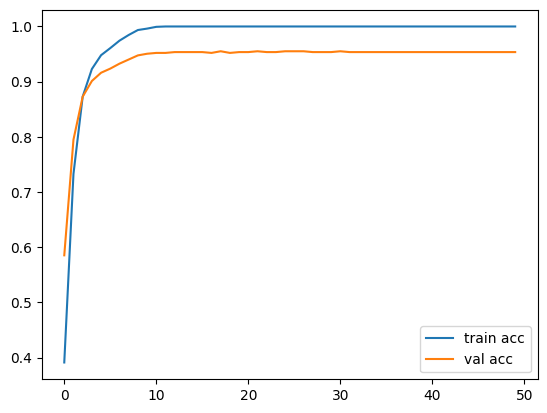

In [15]:
# Plot accuracy per iteration
plt.plot(r.history['accuracy'], label='train acc')
plt.plot(r.history['val_accuracy'], label='val acc')
plt.legend();